The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


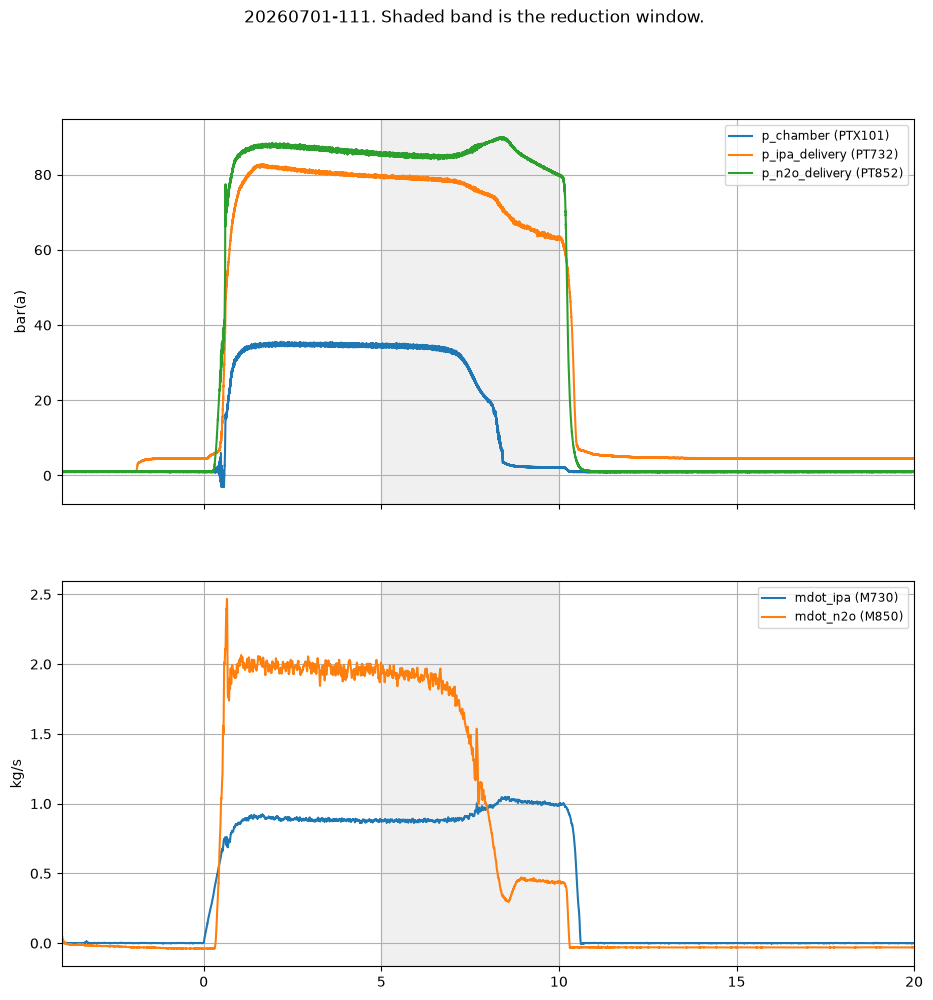

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from otp.experiments.loaders.airborne import load_run


from data.Integza20260630.integza20260630 import CHANNEL_MAP, DATA_PATH
run = load_run(DATA_PATH, cmap=CHANNEL_MAP)
STEADY_STATE_START, STEADY_STATE_END = (5.0, 10.0)
STEADY_STATE = (STEADY_STATE_START, STEADY_STATE_END)

import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 1, figsize=(11, 11), sharex=True)

import pandas as pd
for n in ("p_chamber", "p_ipa_delivery", "p_n2o_delivery"):
    axs[0].plot(run[n].t, run[n].v, label=f"{n} ({run[n].source})")
axs[0].set_ylabel("bar(a)")

for n in ("mdot_ipa", "mdot_n2o"):
    axs[1].plot(run[n].t, run[n].v, label=f"{n} ({run[n].source})")
axs[1].set_ylabel("kg/s")

for ax in axs:
    ax.grid(True); ax.legend(fontsize="small", loc="upper right")
    ax.axvspan(*STEADY_STATE, color="k", alpha=0.06)
axs[0].set_xlim(-4, 20)
fig.suptitle("20260701-111. Shaded band is the reduction window.");
plt.show()

# Find average values over the steady state window
# dp_average = run["dp_pump"].average(*STEADY_STATE)
# avg_dp = run["dp_pump"].mean(STEADY_STATE_START, STEADY_STATE_END)
# avg_Q = run["Q_pump"].mean(STEADY_STATE_START, STEADY_STATE_END)
# avg_rpm = run["rpm"].mean(STEADY_STATE_START, STEADY_STATE_END)
# avg_p_inlet = run["p_pump_in"].mean(STEADY_STATE_START, STEADY_STATE_END)
# max_dp = run["dp_pump"].max(STEADY_STATE_START, STEADY_STATE_END)
# min_dp = run["dp_pump"].min(STEADY_STATE_START, STEADY_STATE_END)
# avg_p_outlet = run["p_pump_out"].mean(STEADY_STATE_START, STEADY_STATE_END)
# print(f"Average pump pressure rise: {avg_dp:.3f} bar, flow: {avg_Q:.3f} m^3/s, rpm: {avg_rpm:.1f} rpm", f"pump inlet: {avg_p_inlet:.3f} bar, pump outlet: {avg_p_outlet:.3f} bar")
# print (f"Max pump pressure rise: {max_dp:.3f} bar, Min pump pressure rise: {min_dp:.3f} bar")

In [10]:
# say running at 70 bar dp, with 10 bar inlet pressure, that's around 1.7kg/s, so we're dumping 0.8kg/s, I'll need to find, given CD of 0.8, the diameter of the orifice:
import numpy as np
dp = 70 * 1e5 + 10 * 1e5
cd = 0.84
mdot = 1
rho = 785

A_or = mdot / cd / (2 * rho * dp)**0.5
D_or = (4 * A_or / np.pi)**0.5

print(D_or * 1e3, "mm")


3.6776297709665093 mm


In [8]:
import numpy as np
dp = 70 * 1e5 + 10 * 1e5
cd = 0.84
mdot = 2
rho = 1000

A_or = mdot / cd / (2 * rho * dp)**0.5
D_or = (4 * A_or / np.pi)**0.5

print(D_or * 1e3, "mm")


4.89553791511486 mm
